In [36]:
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv("ngpf_data.csv")


In [37]:
df.head()


,Day,Price in Dollars per Million Btu
0,1/3/2022,4.36
1,28/2/2022,4.46
2,25/2/2022,4.63
3,24/2/2022,4.78
4,23/2/2022,4.59


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6321 entries, 0 to 6320
Data columns (total 2 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Day                               6321 non-null   object 
 1   Price in Dollars per Million Btu  6320 non-null   float64
dtypes: float64(1), object(1)
memory usage: 98.9+ KB


In [118]:
df['Price in Dollars per Million Btu'].idxmax()


260

In [117]:
df.loc[[260]] # highest price

,Day,Price in Dollars per Million Btu
260,17/2/2021,23.86


In [119]:
df['Price in Dollars per Million Btu'].idxmin()

5839

In [120]:
df.loc[[5839]] #lowest price

,Day,Price in Dollars per Million Btu
5839,4/12/1998,1.05


# **DATA PREPROCESSING**

In [38]:

# Convert to datetime
df['Day'] = pd.to_datetime(df['Day'], dayfirst=True, errors='coerce')

df = df.dropna(subset=['Day', 'Price in Dollars per Million Btu'])

df = df.rename(columns={'Day': 'Date', 'Price in Dollars per Million Btu': 'Price'})

# Sort by date and set index
df = df.sort_values('Date').reset_index(drop=True)
df.set_index('Date', inplace=True)



In [26]:
"""#convert to PKR
df['Price']=(df['Price']*281.82).astype(int)
df['Price in PKR']=df['Price']
df=df.drop(columns=['Price'])
df.head()"""

,Price in PKR
Date,
1997-01-07,303393
1997-01-08,301805
1997-01-09,286715
1997-01-10,311336
1997-01-13,317690


In [39]:
#Resample to monthly averages
monthly_df = df.resample('M').mean()
print(monthly_df.head())


               Price
Date                
1997-01-31  3.451053
1997-02-28  2.150526
1997-03-31  1.890500
1997-04-30  2.032727
1997-05-31  2.248095


In [23]:
monthly_df['Price'].idxmax()


Timestamp('2005-10-31 00:00:00')

highest mean monthly price was in 2005
confirmed by google as well

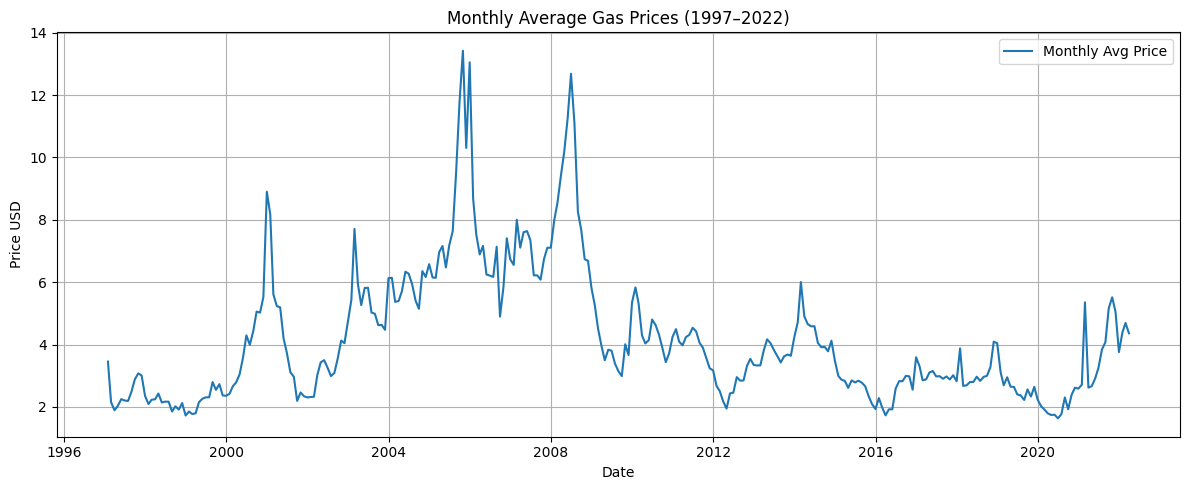

In [6]:
# Monthly trend
plt.figure(figsize=(12, 5))
plt.plot(monthly_df.index, monthly_df['Price'], label='Monthly Avg Price')
plt.title('Monthly Average Gas Prices (1997–2022)')
plt.xlabel('Date')
plt.ylabel('Price USD')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Checking if our data is stationary or not using adfuller

In [24]:
from statsmodels.tsa.stattools import adfuller

# Get the p-value from ADF test
p_value = adfuller(monthly_df['Price'].dropna())[1]
print(f"ADF Test p-value: {p_value:.5f}")


ADF Test p-value: 0.02420


p val was less then 0.05 so no need for differencing data is stationary


Checking for seasonality

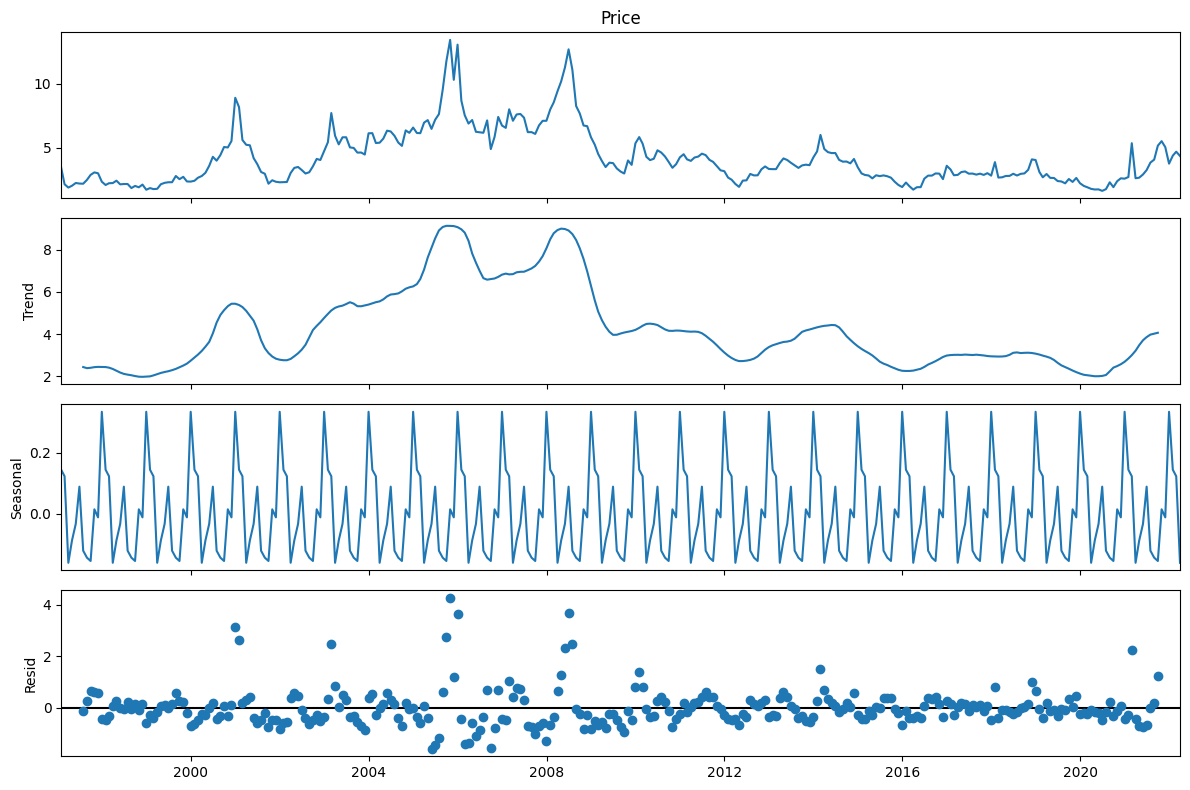

In [25]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(monthly_df['Price'], model='additive', period=12)

# Plot the decomposition: observed, trend, seasonal, residual
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()


We can observe seasonal trend prices have lowest and highest peaks in a complete year. We can further verify by plotting stats for one year


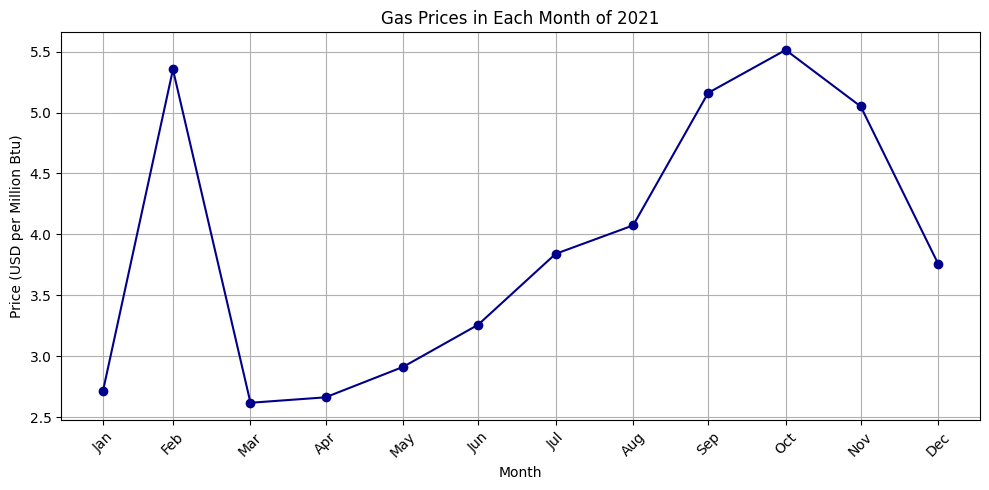

               Price
Date                
2021-01-31  2.712632
2021-02-28  5.353684
2021-03-31  2.618261
2021-04-30  2.662857
2021-05-31  2.912500
2021-06-30  3.258182
2021-07-31  3.840476
2021-08-31  4.074091
2021-09-30  5.161429
2021-10-31  5.513810
2021-11-30  5.050500
2021-12-31  3.757727


In [26]:
#Visualing months where it peaks and dips
selected_year = '2021'#RANDOM
one_year_df = monthly_df.loc[selected_year]

# Plot gas prices for each month in the selected year
plt.figure(figsize=(10, 5))
plt.plot(one_year_df.index, one_year_df['Price'], marker='o', linestyle='-', color='darkblue')
plt.title(f'Gas Prices in Each Month of {selected_year}')
plt.xlabel('Month')
plt.ylabel('Price (USD per Million Btu)')
plt.grid(True)
plt.xticks(one_year_df.index, one_year_df.index.strftime('%b'), rotation=45)
plt.tight_layout()
plt.show()

# Print the data used in the plot
print(one_year_df[['Price']])


it dips in summers and increases in winters.
We can clearly see seasonality


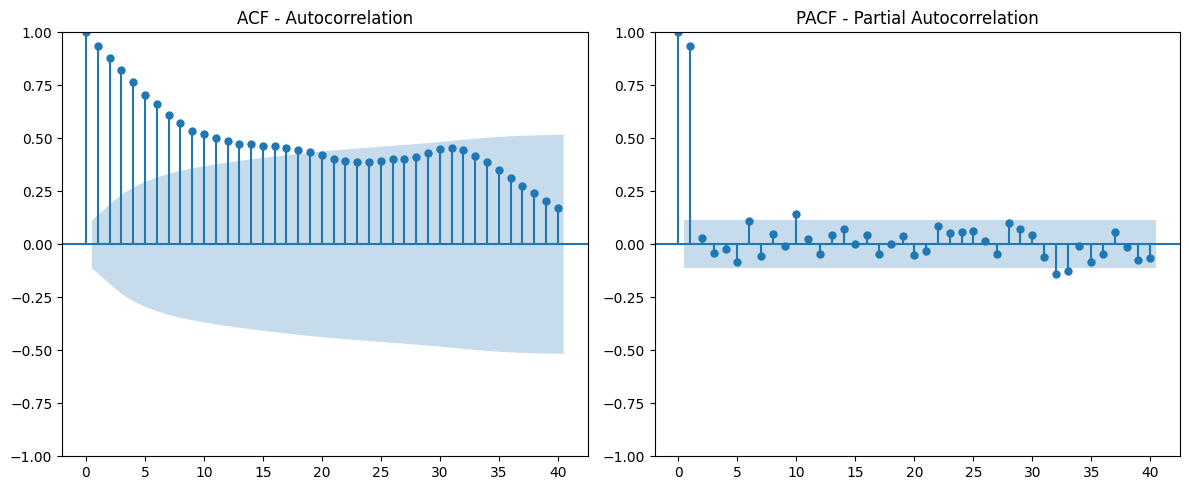

In [131]:
# now I want to see correlation between different time lags
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Use only the 'Price' column from your monthly dataframe
price_series = monthly_df['Price']

# Plot ACF and PACF
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plot_acf(price_series, lags=40, ax=plt.gca())
plt.title('ACF - Autocorrelation')

plt.subplot(1, 2, 2)
plot_pacf(price_series, lags=40, ax=plt.gca(), method='ywm')
plt.title('PACF - Partial Autocorrelation')

plt.tight_layout()
plt.show()


In [40]:
# Train: up to end of 2020, Test: 2021 onward
train = monthly_df[:'2020']
test = monthly_df['2021':]


Starting with SARIMA as it can handle seasonality well(we have seasonality in data)

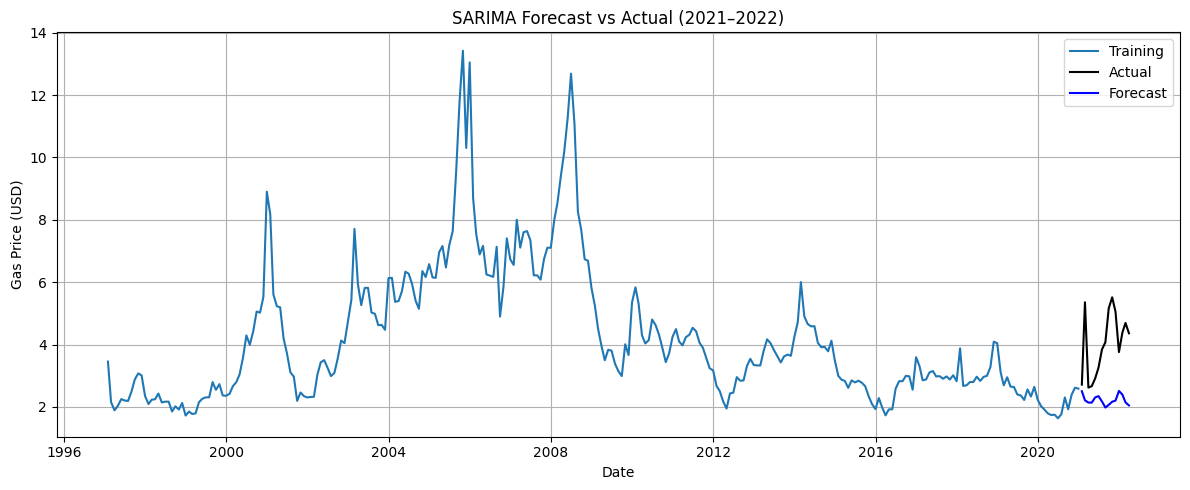

In [41]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

model = SARIMAX(train['Price'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
result = model.fit(disp=False)

forecast = result.get_forecast(steps=len(test))
forecast_mean = forecast.predicted_mean

#plot
plt.figure(figsize=(12, 5))
plt.plot(train.index, train['Price'], label='Training')
plt.plot(test.index, test['Price'], label='Actual', color='black')
plt.plot(forecast_mean.index, forecast_mean, label='Forecast', color='blue')
plt.title('SARIMA Forecast vs Actual (2021–2022)')
plt.xlabel('Date')
plt.ylabel('Gas Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



# **HYPER PARAMETER TUNING USING OPTUNA**

In [42]:
import optuna
import warnings
warnings.filterwarnings("ignore")

def objective(trial):
    p = trial.suggest_int('p', 0, 2)
    d = trial.suggest_int('d', 0, 1)
    q = trial.suggest_int('q', 0, 2)
    P = trial.suggest_int('P', 0, 2)
    D = trial.suggest_int('D', 0, 1)
    Q = trial.suggest_int('Q', 0, 2)
    s = 12  # monthly seasonality

    try:
        model = SARIMAX(train['Price'],
                        order=(p, d, q),
                        seasonal_order=(P, D, Q, s),
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        result = model.fit(disp=False)
        return result.aic
    except:
        return float("inf")


study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print("Best Parameters:", study.best_params)
print("Best AIC:", study.best_value)


[I 2025-05-01 12:31:04,268] A new study created in memory with name: no-name-a7703b89-0317-4a5b-a957-b7e87516926b
[I 2025-05-01 12:31:05,509] Trial 0 finished with value: 622.1458571190317 and parameters: {'p': 1, 'd': 0, 'q': 2, 'P': 1, 'D': 1, 'Q': 1}. Best is trial 0 with value: 622.1458571190317.
[I 2025-05-01 12:31:05,590] Trial 1 finished with value: 620.7347091810857 and parameters: {'p': 0, 'd': 1, 'q': 0, 'P': 1, 'D': 0, 'Q': 0}. Best is trial 1 with value: 620.7347091810857.
[I 2025-05-01 12:31:07,939] Trial 2 finished with value: 602.847760671507 and parameters: {'p': 1, 'd': 0, 'q': 1, 'P': 2, 'D': 1, 'Q': 1}. Best is trial 2 with value: 602.847760671507.
[I 2025-05-01 12:31:09,458] Trial 3 finished with value: 601.2383792648246 and parameters: {'p': 0, 'd': 1, 'q': 0, 'P': 0, 'D': 1, 'Q': 2}. Best is trial 3 with value: 601.2383792648246.
[I 2025-05-01 12:31:11,051] Trial 4 finished with value: 616.5982002469709 and parameters: {'p': 2, 'd': 1, 'q': 2, 'P': 1, 'D': 0, 'Q':

Best Parameters: {'p': 2, 'd': 0, 'q': 0, 'P': 0, 'D': 1, 'Q': 2}
Best AIC: 600.7781183239181


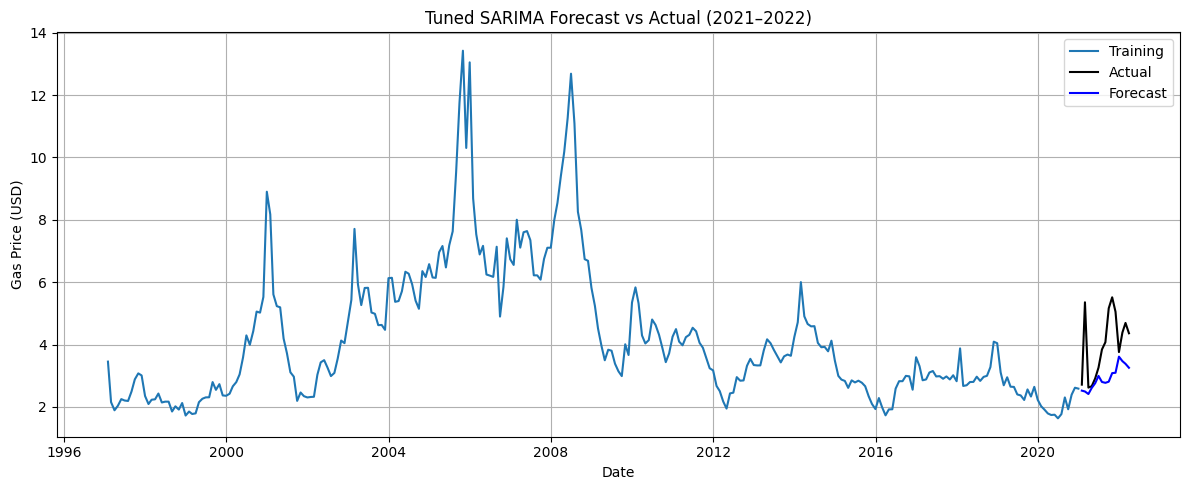

In [43]:

best_params = study.best_params
p, d, q = best_params['p'], best_params['d'], best_params['q']
P, D, Q, s = best_params['P'], best_params['D'], best_params['Q'], 12

model = SARIMAX(train['Price'],
                order=(p, d, q),
                seasonal_order=(P, D, Q, s),
                enforce_stationarity=False,
                enforce_invertibility=False)
result = model.fit(disp=False)

forecast = result.get_forecast(steps=len(test))
forecast_mean = forecast.predicted_mean

#Plot results
plt.figure(figsize=(12, 5))
plt.plot(train.index, train['Price'], label='Training')
plt.plot(test.index, test['Price'], label='Actual', color='black')
plt.plot(forecast_mean.index, forecast_mean, label='Forecast', color='blue')
plt.title('Tuned SARIMA Forecast vs Actual (2021–2022)')
plt.xlabel('Date')
plt.ylabel('Gas Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()





In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(test['Price'], forecast_mean)
rmse = np.sqrt(mean_squared_error(test['Price'], forecast_mean))
mape = np.mean(np.abs((test['Price'] - forecast_mean) / test['Price'])) * 100

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE:  1.09
RMSE: 1.42
MAPE: 23.31%


SARIMA is working perfectly. However to be sure we can compare with other models such as prophet

In [55]:
!pip install prophet --quiet


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpzqs6vnmh/evhvowra.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpzqs6vnmh/es497qt8.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=20894', 'data', 'file=/tmp/tmpzqs6vnmh/evhvowra.json', 'init=/tmp/tmpzqs6vnmh/es497qt8.json', 'output', 'file=/tmp/tmpzqs6vnmh/prophet_modelv2cck014/prophet_model-20250501122155.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
12:21:55 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
12:21:55 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


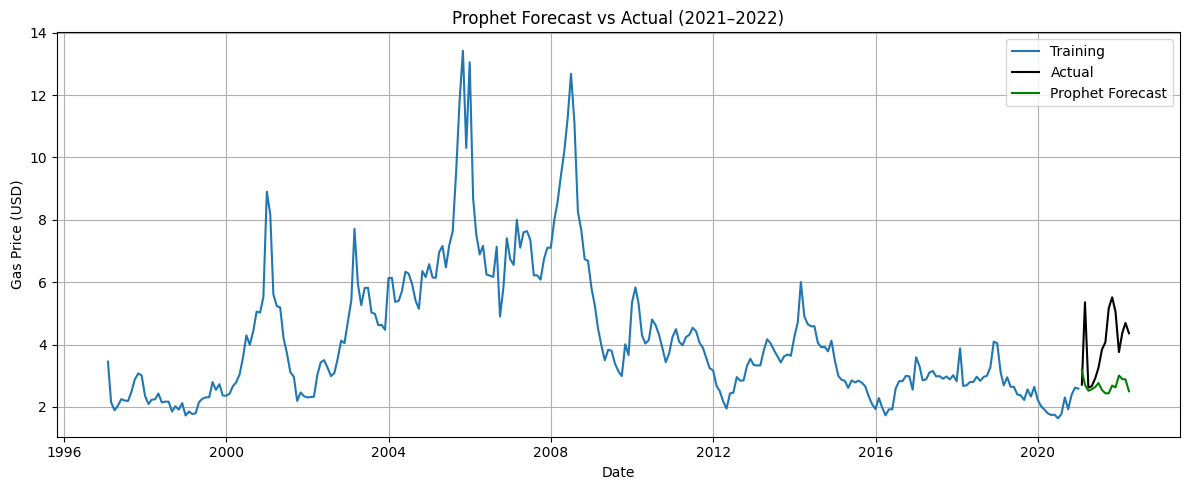

In [29]:
#trying prophet
from prophet import Prophet

# Prepare the data for Prophet
prophet_df = monthly_df.reset_index()[['Date', 'Price']]
prophet_df.columns = ['ds', 'y']

prophet_model = Prophet()
prophet_model.fit(prophet_df)

future = prophet_model.make_future_dataframe(periods=len(test), freq='M')
forecast = prophet_model.predict(future)

forecast_filtered = forecast.set_index('ds').loc[test.index]

# Plot Prophet forecast vs actual
plt.figure(figsize=(12, 5))
plt.plot(train.index, train['Price'], label='Training')
plt.plot(test.index, test['Price'], label='Actual', color='black')
plt.plot(forecast_filtered.index, forecast_filtered['yhat'], label='Prophet Forecast', color='green')
plt.title('Prophet Forecast vs Actual (2021–2022)')
plt.xlabel('Date')
plt.ylabel('Gas Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Calculate accuracy metrics
mae = mean_absolute_error(test['Price'], forecast_filtered['yhat'])
rmse = np.sqrt(mean_squared_error(test['Price'], forecast_filtered['yhat']))
mape = np.mean(np.abs((test['Price'] - forecast_filtered['yhat']) / test['Price'])) * 100




In [30]:
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")


MAE:  1.39
RMSE: 1.69
MAPE: 30.69%


SARIMA is better


Future prediction

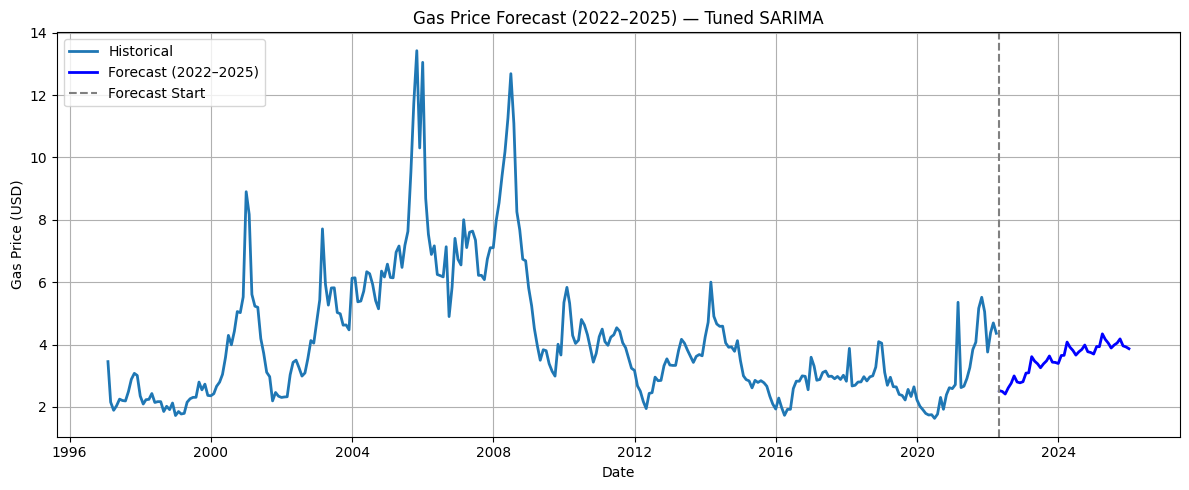

In [47]:
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Combine historical data
historical = pd.concat([train, test])
historical = historical.sort_index()
last_date = historical.index.max()

#Create future forecast
future_steps = 45
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=future_steps, freq='MS')
future_result = result.get_forecast(steps=future_steps)
future_forecast = pd.Series(future_result.predicted_mean.values, index=future_dates)

plt.figure(figsize=(12, 5))
plt.plot(historical.index, historical['Price'], label='Historical', linewidth=2)
plt.plot(future_forecast.index, future_forecast.values, label='Forecast (2022–2025)', color='blue', linewidth=2)

# Step 4: Add vertical line at forecast start
plt.axvline(x=future_forecast.index[0], color='gray', linestyle='--', label='Forecast Start')


plt.title('Gas Price Forecast (2022–2025) — Tuned SARIMA')
plt.xlabel('Date')
plt.ylabel('Gas Price (USD)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


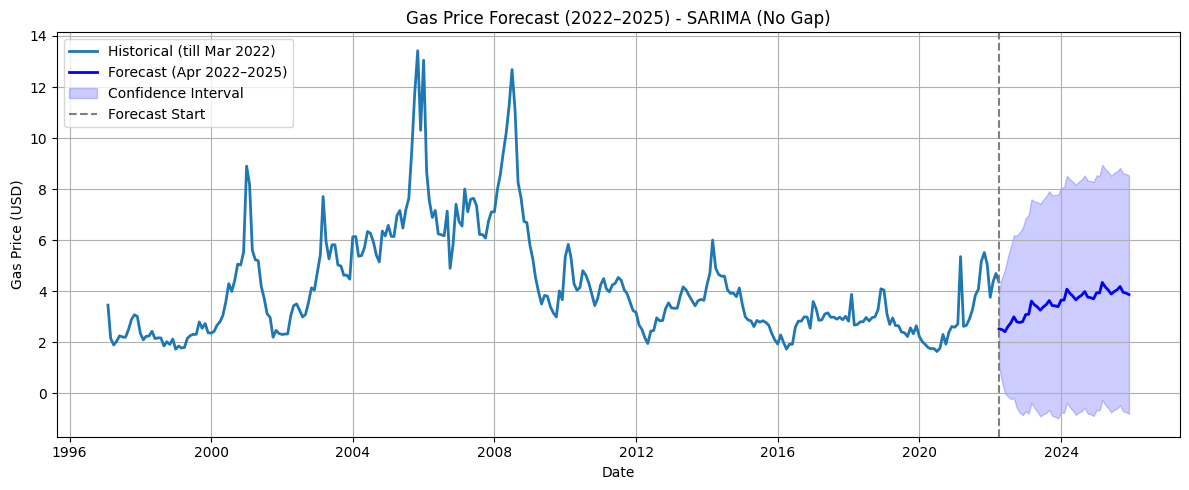

In [48]:
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Combine historical data
historical = pd.concat([train, test])
historical = historical.sort_index()
last_actual_date = pd.to_datetime('2022-03-01')  # confirmed endpoint

# Step 2: Forecast 45 months (Apr 2022 – Dec 2025)
future_steps = 45
future_dates = pd.date_range(start=last_actual_date + pd.DateOffset(months=1), periods=future_steps, freq='MS')
sarima_forecast = result.get_forecast(steps=future_steps)
forecast_mean = pd.Series(sarima_forecast.predicted_mean.values, index=future_dates)

# Step 3: Plot historical + forecast
plt.figure(figsize=(12, 5))
plt.plot(historical.index, historical['Price'], label='Historical (till Mar 2022)', linewidth=2)
plt.plot(forecast_mean.index, forecast_mean.values, label='Forecast (Apr 2022–2025)', color='blue', linewidth=2)

# Optional: Add confidence intervals if needed
conf_int = sarima_forecast.conf_int()
plt.fill_between(
    future_dates,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color='blue',
    alpha=0.2,
    label='Confidence Interval'
)

# Add vertical line at forecast start
plt.axvline(x=forecast_mean.index[0], color='gray', linestyle='--', label='Forecast Start')

# Final layout
plt.title('Gas Price Forecast (2022–2025) - SARIMA (No Gap)')
plt.xlabel('Date')
plt.ylabel('Gas Price (USD)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


with prophet

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpwdjx_f3v/f133yv1x.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpwdjx_f3v/_t3_34ir.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=80662', 'data', 'file=/tmp/tmpwdjx_f3v/f133yv1x.json', 'init=/tmp/tmpwdjx_f3v/_t3_34ir.json', 'output', 'file=/tmp/tmpwdjx_f3v/prophet_modelijtd6yvt/prophet_model-20250501111345.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
11:13:45 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
11:13:45 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


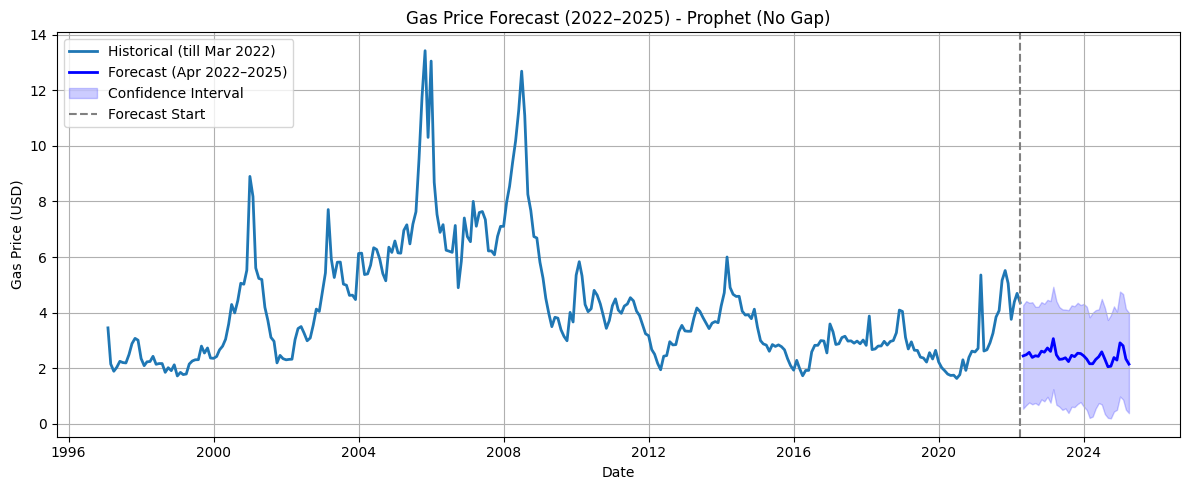

In [107]:
from prophet import Prophet
import matplotlib.pyplot as plt
import pandas as pd


df = monthly_df.reset_index().rename(columns={'Date': 'ds', 'Price': 'y'})
model = Prophet()
model.fit(df)

# Forecast 36 months ahead
future = model.make_future_dataframe(periods=36, freq='M')
forecast = model.predict(future)
forecast.set_index('ds', inplace=True)


last_actual_date = pd.to_datetime('2022-03-01')

# Start forecast immediately after last actual
forecast_start = last_actual_date + pd.DateOffset(months=1)
forecast_range = forecast.loc[forecast_start:'2025-12-31']

# Plot actual and forecasted
plt.figure(figsize=(12, 5))
plt.plot(monthly_df.index, monthly_df['Price'], label='Historical (till Mar 2022)', linewidth=2)
plt.plot(forecast_range.index, forecast_range['yhat'], label='Forecast (Apr 2022–2025)', color='blue', linewidth=2)
plt.fill_between(
    forecast_range.index,
    forecast_range['yhat_lower'],
    forecast_range['yhat_upper'],
    color='blue', alpha=0.2, label='Confidence Interval'
)

plt.axvline(x=forecast_start, color='gray', linestyle='--', label='Forecast Start')
plt.title('Gas Price Forecast (2022–2025) - Prophet (No Gap)')
plt.xlabel('Date')
plt.ylabel('Gas Price (USD)')
plt.grid(True)
plt.legend()


plt.tight_layout()
plt.show()


# **REST IS JUST DEPLOYING DASHBOARD**

In [61]:
!pip install streamlit prophet pyngrok --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 2.0 MB/s eta 0:00:00


In [49]:
%%writefile app.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import streamlit as st
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings

warnings.filterwarnings("ignore")

st.set_page_config(page_title="Gas Price Forecast", layout="wide")
st.title("📉 Gas Price Forecast Dashboard (SARIMA)")

# Load your prepared dataset
@st.cache_data
def load_data():
    from datetime import datetime
    # Simulated monthly gas price data (replace this with your real dataset)
    dates = pd.date_range(start="1997-01-01", periods=300, freq="MS")
    prices = np.clip(np.random.normal(4, 1, len(dates)), 1, 8)
    df = pd.DataFrame({"Date": dates, "Price": prices})
    df.set_index("Date", inplace=True)
    return df

data = load_data()

# Sidebar
st.sidebar.header("Model Configuration")
forecast_months = st.sidebar.slider("Forecast Horizon (Months)", 12, 60, 36)

# Train SARIMA Model (default example order, replace with your best)
order = (1, 1, 1)
seasonal_order = (1, 1, 1, 12)

model = SARIMAX(data['Price'], order=order, seasonal_order=seasonal_order,
                enforce_stationarity=False, enforce_invertibility=False)
results = model.fit(disp=False)

# Forecast future values
last_date = data.index.max()
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=forecast_months, freq="MS")
forecast = results.get_forecast(steps=forecast_months)
forecast_mean = pd.Series(forecast.predicted_mean.values, index=future_dates)
conf_int = forecast.conf_int()

# Combine forecast into DataFrame
forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecasted_Price": forecast_mean,
    "Lower": conf_int.iloc[:, 0].values,
    "Upper": conf_int.iloc[:, 1].values
})
forecast_df.set_index("Date", inplace=True)

# Date filter
min_date = forecast_df.index.min()
max_date = forecast_df.index.max()
date_range = st.sidebar.date_input("Select Date Range", [min_date, max_date],
                                   min_value=min_date, max_value=max_date)

filtered = forecast_df.loc[pd.to_datetime(date_range[0]):pd.to_datetime(date_range[1])]

# Line chart
st.subheader("Forecasted Gas Prices")
st.line_chart(filtered[["Forecasted_Price"]], use_container_width=True)

# Confidence interval
if st.checkbox("Show confidence interval"):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(filtered.index, filtered["Forecasted_Price"], label="Forecast")
    ax.fill_between(filtered.index, filtered["Lower"], filtered["Upper"],
                    color='blue', alpha=0.2, label="Confidence Interval")
    ax.set_xlabel("Date")
    ax.set_ylabel("Price (USD)")
    ax.set_title("Forecast with Confidence Interval")
    ax.legend()
    st.pyplot(fig)

# Download button
csv = filtered[["Forecasted_Price"]].reset_index().rename(columns={"Date": "Date"})
st.download_button("📥 Download Forecast CSV", csv.to_csv(index=False), "sarima_forecast.csv", "text/csv")


Overwriting app.py


In [50]:
from pyngrok import ngrok
ngrok.set_auth_token("2wUSpIo75Zgx0Vc75PpkOp0Yneh_7RWvYHP5YPGH2LCuMsLok")

In [51]:
from pyngrok import ngrok

# Kill any previous tunnels
ngrok.kill()

# Start Streamlit app in background
!streamlit run app.py &>/content/logs.txt &

# ✅ Use updated connect method
public_url = ngrok.connect("http://localhost:8501")
print(f"🌐 Streamlit app is live at: {public_url}")


🌐 Streamlit app is live at: NgrokTunnel: "https://dbbb-34-80-47-11.ngrok-free.app" -> "http://localhost:8501"
